# Customer Analytics — Level 3: Customer Retention Analysis
### *The Loyalty Test: Are customers actually coming back?*

This analysis builds directly upon our findings in Levels 1 & 2. Having established that our new customer acquisition peaked early and became highly volatile, we must now answer the CFO's core question: **How strong is our customer retention over time?**

> **A Note on Methodology:** In Level 1, we used a simple proxy for "Retention Rate" (customers active within the last 90 days). In this chapter, we upgrade to rigorous, industry-standard metrics: **Month-over-Month (MoM) Retention** and **Cohort Retention**. This will expose exactly when customers churn and how many stick around to become long-term revenue drivers.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

sns.set_theme(style="whitegrid", palette="deep")
sns.set_context("talk")

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titleweight'] = 'bold'

pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
pd.set_option('display.max_columns',None)

df = pd.read_csv("data/raw/online_retail_clean.csv", parse_dates=["InvoiceDate"])
df["InvoiceMonth"] = df["InvoiceDate"].dt.to_period("M")

# Cohort month = The first Transaction month of each customer
first_purchase = df.groupby("CustomerID")["InvoiceMonth"].min().reset_index()
first_purchase.columns = ["CustomerID", "CohortMonth"]
df = df.merge(first_purchase, on="CustomerID")

print(f"Total customers : {df['CustomerID'].nunique():,}")
print(f"Total months    : {df['InvoiceMonth'].nunique()}")
df.head()

Total customers : 4,338
Total months    : 13


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Profit,InvoiceMonth,InvoiceDateOnly,DayOfWeek,Hour,CohortMonth
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,6.02,2010-12,2010-12-01,Wednesday,8,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,10.94,2010-12,2010-12-01,Wednesday,8,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,10.63,2010-12,2010-12-01,Wednesday,8,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,9.15,2010-12,2010-12-01,Wednesday,8,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,6.90,2010-12,2010-12-01,Wednesday,8,2010-12


## 1. The Active Customer Mix (Returning vs. New)

A healthy business should see a growing proportion of its monthly active users coming from *returning* customers, especially if new acquisition is slowing down. Let's look at the composition of our active buyers month by month.

In [2]:
active_per_month = df.groupby("InvoiceMonth")["CustomerID"].agg(set).reset_index()
active_per_month.columns = ["Month", "ActiveCustomers"]
months = active_per_month["Month"].tolist()

rows = []
for i, m in enumerate(months):
    active_now = active_per_month.loc[active_per_month["Month"] == m, "ActiveCustomers"].values[0]
    new_now = set(first_purchase.loc[first_purchase["CohortMonth"] == m, "CustomerID"])
    returning_now = active_now - new_now

    if i > 0:
        active_prev = active_per_month.loc[active_per_month["Month"] == months[i-1], "ActiveCustomers"].values[0]
        retained = active_prev & active_now
        mom_retention = len(retained) / len(active_prev) * 100 if len(active_prev) > 0 else np.nan
        mom_churn = 100 - mom_retention
    else:
        mom_retention, mom_churn = np.nan, np.nan

    rows.append({
        "Month": m, "TotalActive": len(active_now), "NewCustomers": len(new_now),
        "ReturningCustomers": len(returning_now),
        "MoM_RetentionRate%": mom_retention, "MoM_ChurnRate%": mom_churn
    })

monthly_summary = pd.DataFrame(rows)
monthly_summary["MonthStr"] = monthly_summary["Month"].astype(str)
monthly_summary

,Month,TotalActive,NewCustomers,ReturningCustomers,MoM_RetentionRate%,MoM_ChurnRate%,MonthStr
0,2010-12,885,885,0,NaN,NaN,2010-12
1,2011-01,741,417,324,36.61,63.39,2011-01
2,2011-02,758,380,378,35.36,64.64,2011-02
3,2011-03,974,452,522,38.26,61.74,2011-03
4,2011-04,856,300,556,31.21,68.79,2011-04
5,2011-05,1056,284,772,42.99,57.01,2011-05
6,2011-06,991,242,749,38.83,61.17,2011-06
7,2011-07,949,188,761,36.83,63.17,2011-07
8,2011-08,935,169,766,40.89,59.11,2011-08
9,2011-09,1266,299,967,45.45,54.55,2011-09


**Visualizing the Active Customer Mix:**

As the chart below will show, returning customers contribute a significant share of monthly activity, highlighting the importance of repeat purchases in sustaining business performance.

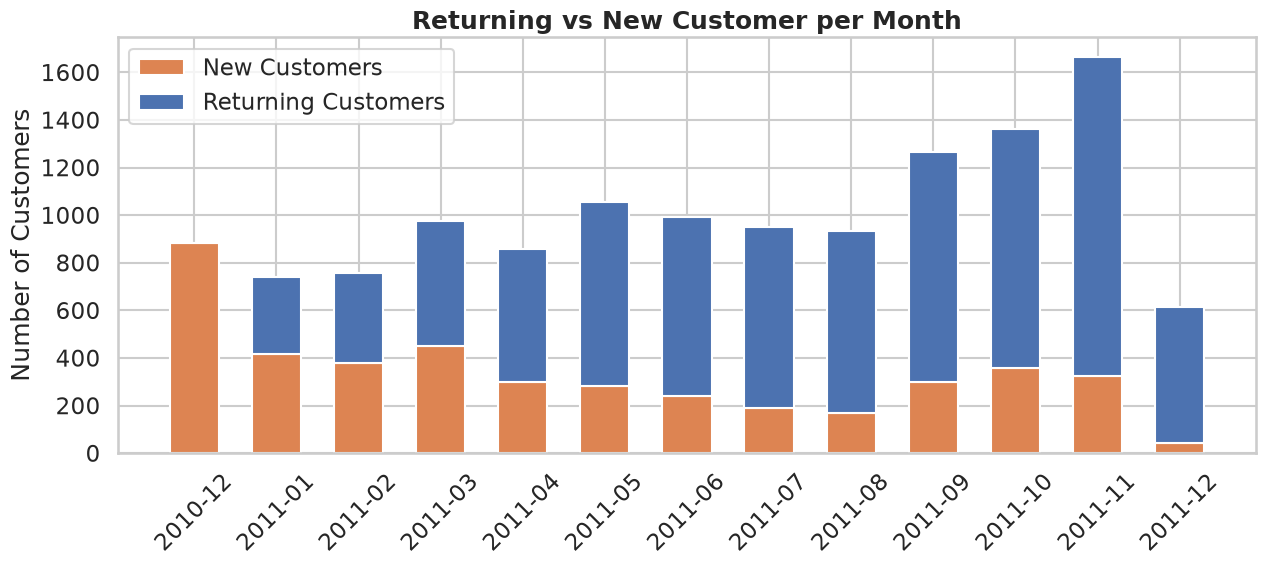

Rata-rata proporsi returning customer per bulan: 65.2%


In [3]:
fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(monthly_summary))
width = 0.6

ax.bar(x, monthly_summary["NewCustomers"], width, label="New Customers", color="#DD8452")
ax.bar(x, monthly_summary["ReturningCustomers"], width, bottom=monthly_summary["NewCustomers"],
       label="Returning Customers", color="#4C72B0")

ax.set_xticks(x)
ax.set_xticklabels(monthly_summary["MonthStr"], rotation=45)
ax.set_title("Returning vs New Customer per Month")
ax.set_ylabel("Number of Customers")
ax.legend()
plt.tight_layout()
plt.savefig("pictures/level3_returning_vs_new.png", dpi=120, bbox_inches='tight')
plt.show()

pct_returning = (monthly_summary["ReturningCustomers"] / monthly_summary["TotalActive"] * 100).mean()
print(f"Rata-rata proporsi returning customer per bulan: {pct_returning:.1f}%")

## 2. The Macro Repeat Purchase Rate

Before we slice the data into cohorts, let's look at the macro view. Out of everyone who has ever bought from us, how many have come back to buy a second time?

In [4]:
cust_orders = df.groupby("CustomerID")["InvoiceNo"].nunique().reset_index(name="NumOrders")
total_customers = cust_orders["CustomerID"].nunique()
returning_customers = (cust_orders["NumOrders"] > 1).sum()
repeat_purchase_rate = returning_customers / total_customers * 100

print(f"Amount Customers              : {total_customers:,}")
print(f"Customers with >1 order     : {returning_customers:,}")
print(f"Repeat Purchase Rate          : {repeat_purchase_rate:.2f}%")

Amount Customers              : 4,338
Customers with >1 order     : 2,845
Repeat Purchase Rate          : 65.58%


## 3. Cohort Retention Analysis (The "Layer Cake")

To truly understand loyalty, we must use **Cohort Analysis**. We group customers by the month they made their very first purchase (their "Cohort"). Then, we track what percentage of that specific group returned in Month 1, Month 2, Month 3, and so on.

This is the ultimate lie-detector test for a business. It tells us if newer cohorts are churning faster than older ones, and at what exact month we typically lose a customer.

In [5]:
def month_diff(later, earlier):
    return (later.year - earlier.year) * 12 + (later.month - earlier.month)

df["CohortIndex"] = df.apply(lambda r: month_diff(r["InvoiceMonth"], r["CohortMonth"]), axis=1)

cohort_data = df.groupby(["CohortMonth", "CohortIndex"])["CustomerID"].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index="CohortMonth", columns="CohortIndex", values="CustomerID")
cohort_size = cohort_pivot[0]

retention_table = cohort_pivot.divide(cohort_size, axis=0) * 100
retention_table.index = retention_table.index.astype(str)

retention_table.round(1)

CohortIndex,0,1,2,3,4,5,6,7,8,9,10,11,12
CohortMonth,,,,,,,,,,,,,
2010-12,100.00,36.60,32.30,38.40,36.30,39.80,36.30,34.90,35.40,39.50,37.40,50.30,26.60
2011-01,100.00,22.10,26.60,23.00,32.10,28.80,24.70,24.20,30.00,32.60,36.50,11.80,NaN
2011-02,100.00,18.70,18.70,28.40,27.10,24.70,25.30,27.90,24.70,30.50,6.80,NaN,NaN
2011-03,100.00,15.00,25.20,19.90,22.30,16.80,26.80,23.00,27.90,8.60,NaN,NaN,NaN
2011-04,100.00,21.30,20.30,21.00,19.70,22.70,21.70,26.00,7.30,NaN,NaN,NaN,NaN
2011-05,100.00,19.00,17.30,17.30,20.80,23.20,26.40,9.50,NaN,NaN,NaN,NaN,NaN
2011-06,100.00,17.40,15.70,26.40,23.10,33.50,9.50,NaN,NaN,NaN,NaN,NaN,NaN
2011-07,100.00,18.10,20.70,22.30,27.10,11.20,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-08,100.00,20.70,24.90,24.30,12.40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Visualizing the Customer Lifespan:**
Read the rows from left to right to see how a specific group of customers degrades over time. Read the columns top to bottom to compare if our retention efforts are improving for newer cohorts.

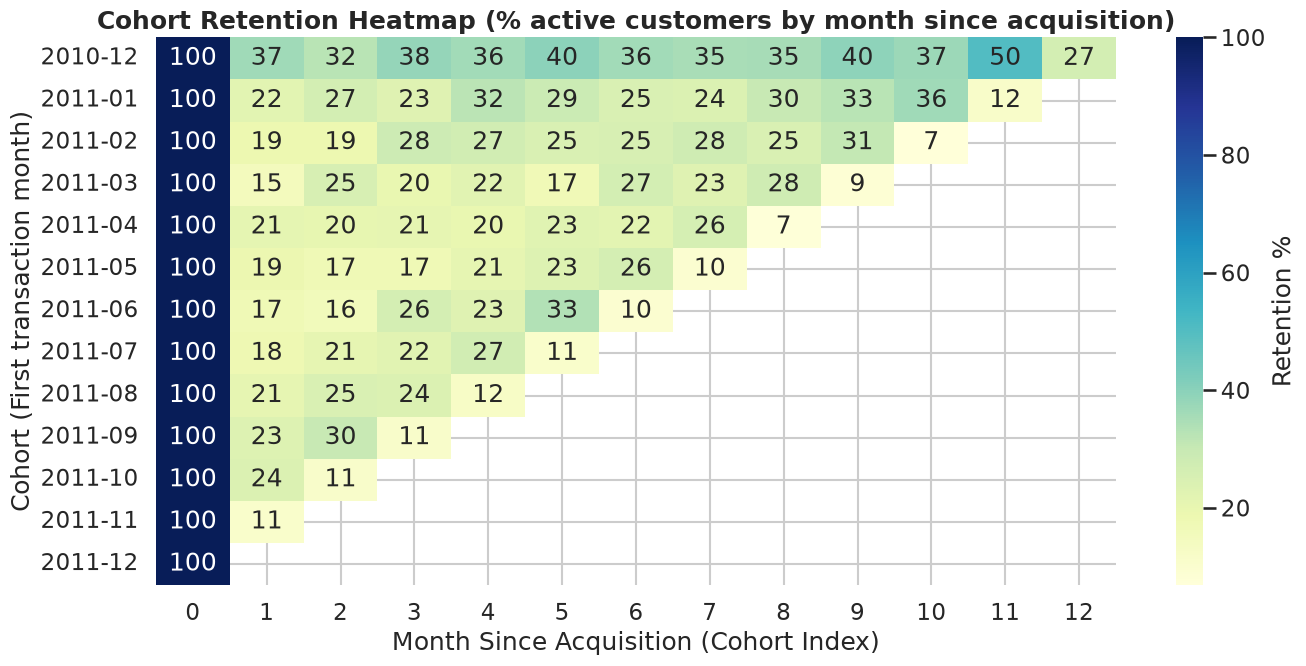

In [6]:
fig, ax = plt.subplots(figsize=(14, 7))
sns.heatmap(retention_table, annot=True, fmt=".0f", cmap="YlGnBu", cbar_kws={'label': 'Retention %'}, ax=ax)
ax.set_title("Cohort Retention Heatmap (% active customers by month since acquisition)")
ax.set_xlabel("Month Since Acquisition (Cohort Index)")
ax.set_ylabel("Cohort (First transaction month)")
plt.tight_layout()
plt.savefig("pictures/level3_cohort_heatmap.png", dpi=120, bbox_inches='tight')
plt.show()

**The Average Retention Curve (The "Cliff" and The "Floor"):**
By averaging the retention rates across all cohorts, we can visualize the typical lifespan of a customer.

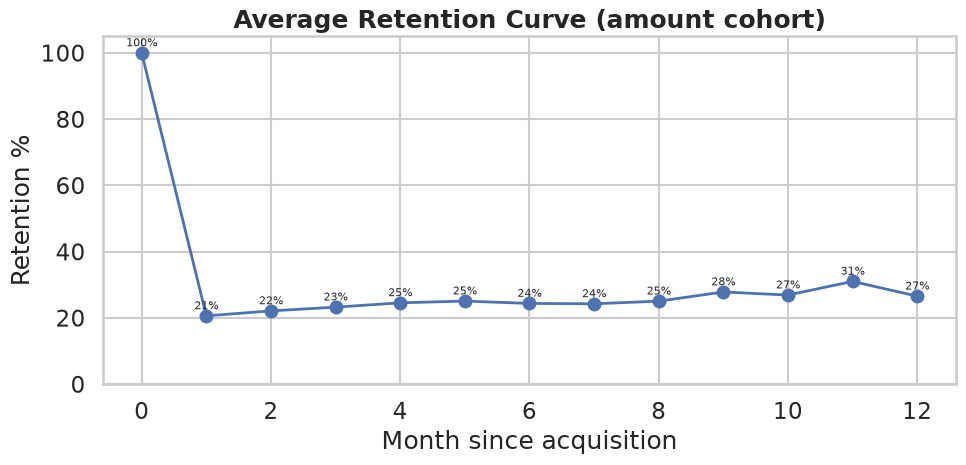

Month retention-1 (avarege every cohort) : 20.6%
Month retention-3                        : 23.2%
Month retention-6                        : 24.4%

Insight: there's a big 'cliff drop' from month 0 to month 1 — this is very common in retail/e-commerce.
Customers who pass month 1 tend to have more stable retention in the following months.


In [8]:
avg_retention_curve = retention_table.mean(axis=0)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(avg_retention_curve.index, avg_retention_curve.values, marker="o", color="#4C72B0", linewidth=2)
ax.set_title("Average Retention Curve (amount cohort)")
ax.set_xlabel("Month since acquisition")
ax.set_ylabel("Retention %")
ax.set_ylim(0, 105)
for x_, y_ in zip(avg_retention_curve.index, avg_retention_curve.values):
    ax.text(x_, y_+2, f"{y_:.0f}%", ha='center', fontsize=8)
plt.tight_layout()
plt.savefig("pictures/level3_retention_curve.png", dpi=120, bbox_inches='tight')
plt.show()

print(f"Month retention-1 (avarege every cohort) : {avg_retention_curve.get(1, float('nan')):.1f}%")
print(f"Month retention-3                        : {avg_retention_curve.get(3, float('nan')):.1f}%")
print(f"Month retention-6                        : {avg_retention_curve.get(6, float('nan')):.1f}%")
print("\nInsight: there's a big 'cliff drop' from month 0 to month 1 — this is very common in retail/e-commerce.")
print("Customers who pass month 1 tend to have more stable retention in the following months.")

## 4. Purchase Frequency (The Skewed Reality)

We know that ~65% of our customers return. But *how often* do they return? In a B2B/Wholesaler environment, average metrics can be deeply misleading because a few massive buyers can skew the numbers. Let's look at the distribution of order frequency.

In [9]:
total_orders = df["InvoiceNo"].nunique()
purchase_frequency = total_orders / total_customers

print(f"Amount Orders        : {total_orders:,}")
print(f"Amount Customers      : {total_customers:,}")
print(f"Purchase Frequency   : {purchase_frequency:.2f} orders/customer")
print()
print(cust_orders["NumOrders"].describe().round(2))

Amount Orders        : 18,532
Amount Customers      : 4,338
Purchase Frequency   : 4.27 orders/customer

count   4,338.00
mean        4.27
std         7.70
min         1.00
25%         1.00
50%         2.00
75%         5.00
max       209.00
Name: NumOrders, dtype: float64


**Visualizing the Order Distribution:**

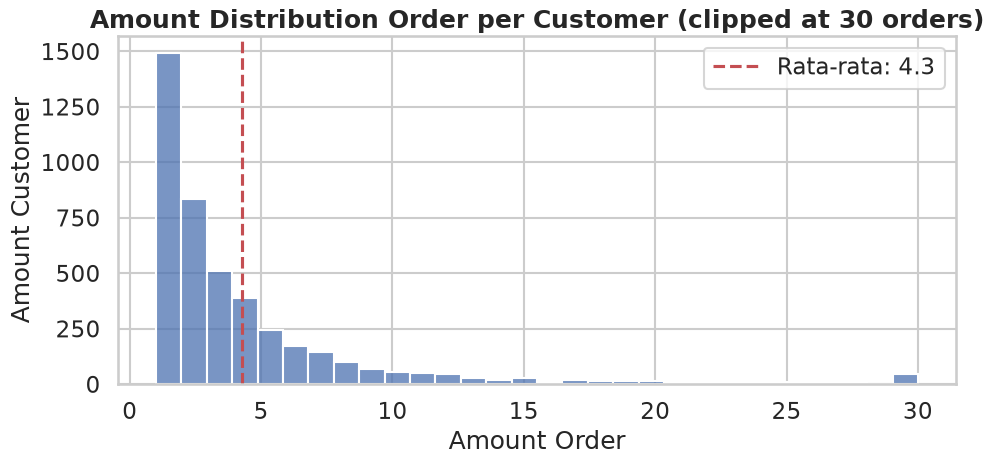

Customer dengan tepat 1 order: 34.4% dari total customer


In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
# Clip di 30 order biar histogram tidak didominasi outlier ekstrem (ada yang sampai 209 order)
clipped = cust_orders["NumOrders"].clip(upper=30)
sns.histplot(clipped, bins=30, color="#4C72B0", ax=ax)
ax.axvline(purchase_frequency, color="#C44E52", linestyle="--", label=f"Rata-rata: {purchase_frequency:.1f}")
ax.set_title("Amount Distribution Order per Customer (clipped at 30 orders)")
ax.set_xlabel("Amount Order")
ax.set_ylabel("Amount Customer")
ax.legend()
plt.tight_layout()
plt.savefig("pictures/level3_order_frequency_dist.png", dpi=120, bbox_inches='tight')
plt.show()

pct_one_order = (cust_orders["NumOrders"] == 1).mean() * 100
print(f"Customer dengan tepat 1 order: {pct_one_order:.1f}% dari total customer")

In [11]:
import os

os.makedirs('data/processed', exist_ok=True)

monthly_summary.to_csv('data/processed/monthly_retention_summary.csv', index=False)

retention_table.to_csv('data/processed/cohort_retention_heatmap.csv')

cust_orders.to_csv('data/processed/customer_purchase_frequency.csv', index=False)

## Executive Summary: The Retention Verdict

**Key Insights for the CFO:**
1. **The "Cliff Drop" Reality:** Our retention curve shows a sharp decline between the initial purchase period and the following month, indicating that a substantial portion of newly acquired customers do not return for a second purchase. This means a large chunk of newly acquired customers try us once and never return. 
2. **The Solid "Floor":** The good news is that if a customer survives past Month 1, Customers who remain active beyond the early churn stage exhibit a noticeably more stable retention pattern, forming a loyal customer base that continues purchasing over time. These are our reliable repeaters.
3. **High Dependency on "Whales":** While customers place multiple orders on average during the observation period, purchasing behavior varies substantially across the customer base, the distribution is highly skewed. A substantial share of customers make only a single purchase, highlighting an opportunity to improve onboarding, engagement, and second-purchase conversion, while on the extreme right, At the opposite end of the distribution, a small group of highly active customers generates a disproportionately large number of orders. 

**What's Next? (Moving to Level 4 & 5):**
The retention analysis suggests that a relatively small segment of highly engaged repeat customers may contribute disproportionately to long-term business performance, we must immediately identify who they are. Treating all customers equally in our marketing budget is wasting money on the 34% who will never return. 

In the next chapters, we will:
- **Level 4 — Customer Lifetime Value (CLV):** Map the revenue distribution to prove the Pareto Principle (80/20 rule).
- **Level 5 — RFM Segmentation:** Mechanically segment our database into *Champions*, *At Risk*, and *Lost* so we can deploy targeted retention strategies.